# First, let us set up a few dependencies

Don't forget to switch to a GPU-enabled colab runtime!

```
Runtime -> Change Runtime Type -> GPU
```

# Automatic Labelling Using [SAM3](https://ai.meta.com/sam3/)

## Setup

To be able to use this model you would need to acquire access. Check [the model page](https://huggingface.co/facebook/sam3) to request access and confirm you're approved. To run inference, either set your `HF_TOKEN` as an environment variable/secret or log in using the cell below. If you don't already have a token, follow the [instructions](https://huggingface.co/docs/hub/en/security-tokens) on how to create one.

In [1]:
from huggingface_hub import login
login(new_session=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [2]:
using_colab = True

In [3]:
if using_colab:
    import sys
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    !{sys.executable} -m pip install opencv-python matplotlib scikit-learn decord numpy==1.26.0

    !git clone https://github.com/facebookresearch/sam3.git /content/sam3

    %cd /content/sam3
    !{sys.executable} -m pip install -e .
    %cd /content

    sam3_repo_root = "/content/sam3"
    if sam3_repo_root not in sys.path:
        sys.path.insert(0, sam3_repo_root)

    if 'sam3' in sys.modules:
        del sys.modules['sam3']

PyTorch version: 2.9.0+cu126
Torchvision version: 0.24.0+cu126
CUDA is available: True
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 2.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 125.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 141.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.12.0.88
    Uninstalling opencv-python-4.12.0.88:
      Successfully uninstalled opencv-python-4.12.0.88
ERROR: pip's dependency resolver does not currently take into account all the packages that are installe

In [5]:
import os
import contextlib
@contextlib.contextmanager
def directory(name):
  ret = os.getcwd()
  os.chdir(name)
  yield None
  os.chdir(ret)

import subprocess
def run(input, exception_on_failure=False):
  try:
    program_output = subprocess.check_output(f"{input}", shell=True, universal_newlines=True, stderr=subprocess.STDOUT)
  except Exception as e:
    if exception_on_failure:
      raise e
    program_output = e.output

    return program_output
def prun(input, exception_on_failure=False):
  x = run(input, exception_on_failure)
  print(x)
  return x

## This mounts your google drive to this notebook. You might have to change the path to fit with your dataset folder inside your drive.

Read the instruction output by the cell bellow carefully!

In [6]:
# Mount the drive
from google.colab import drive
drive.mount('/content/drive')
DRIVE_PATH = "/content/drive/MyDrive/dt_object_detection_training" #update the path with the location of zipfile

Mounted at /content/drive


In [7]:
# Unzip the dataset
import shutil
import os


DATASET_DIR_NAME = "duckietown_dataset"
DATASET_ZIP_NAME = f"{DATASET_DIR_NAME}.zip"
DATASET_DIR_PATH = os.path.join("/content", DATASET_DIR_NAME)
TRAIN_DIR = "train"
VALIDATION_DIR = "val"
IMAGES_DIR = "images"
LABELS_DIR = "labels"


def show_info(base_path: str):
  for l1 in [TRAIN_DIR, VALIDATION_DIR]:
    for l2 in [IMAGES_DIR, LABELS_DIR]:
      p = os.path.join(base_path, l1, l2)
      print(f"#Files in {l1}/{l2}: {len(os.listdir(p))}")


def unzip_dataset():
  # check zipped file
  zip_path = os.path.join(DRIVE_PATH, DATASET_ZIP_NAME)
  assert os.path.exists(zip_path), f"No zipped dataset found at {zip_path}! Abort!"

  # unzip the data
  print("Unpacking zipped data...")
  shutil.unpack_archive(zip_path, DATASET_DIR_PATH)
  print(f"Zipped dataset unpacked to {DATASET_DIR_PATH}")

  # show some info
  show_info(DATASET_DIR_PATH)


unzip_dataset()

Unpacking zipped data...
Zipped dataset unpacked to /content/duckietown_dataset
#Files in train/images: 470
#Files in train/labels: 0
#Files in val/images: 118
#Files in val/labels: 0


In [3]:
DATASET_DIR = Path("/content/duckietown_dataset")
TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"
CLASSES_YAML = DATASET_DIR / "classes.yaml"

##Let's create the config file we need for training our duckie detector as well.

In [17]:
%%writefile /content/duckietown_dataset/classes.yaml

# train and val data as 1) directory: path/images/, 2) file: path/images.txt, or 3) list: [path1/images/, path2/images/]
train:  /content/duckietown_dataset/train
val:    /content/duckietown_dataset/val

# class names
names:
  0: 'yellow rubber duck' # you can try adding more classes if you'd like

Overwriting /content/duckietown_dataset/classes.yaml


# Run Auto Labelling using SAM3

In [9]:
import csv
from pathlib import Path

import torch
import yaml
from PIL import Image
from tqdm import tqdm
from glob import glob

from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

In [13]:
def load_classes():
    with open(CLASSES_YAML, "r") as f:
        cfg = yaml.safe_load(f)
    items = sorted(cfg["names"].items(), key=lambda kv: int(kv[0]))
    return [name for _, name in items]


def xyxy_to_yolo_line(bbox, w, h, class_id):
    x1, y1, x2, y2 = bbox
    cx = (x1 + x2) / 2.0 / w
    cy = (y1 + y2) / 2.0 / h
    bw = (x2 - x1) / w
    bh = (y2 - y1) / h
    return f"{class_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}"


def init_sam3(device=None):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    classes = load_classes()
    bpe_path = Path("/content/sam3/assets/bpe_simple_vocab_16e6.txt.gz")
    model = build_sam3_image_model(bpe_path=str(bpe_path))
    model.to(device)
    model.eval()
    processor = Sam3Processor(model, confidence_threshold=0.3, device=device)
    return processor, classes


def detect_sam3(img_path, state):
    processor, classes = state
    image = Image.open(img_path).convert("RGB")
    w, h = image.size
    with torch.no_grad():
        st = processor.set_image(image)
        detections = []
        for class_id, prompt in enumerate(classes):
            out = processor.set_text_prompt(state=st, prompt=prompt)
            boxes = out.get("boxes")
            scores = out.get("scores")
            if boxes is None or scores is None:
                continue
            for b, s in zip(boxes, scores):
                s = float(s)
                if s < processor.confidence_threshold:
                    continue
                detections.append(
                    {
                        "bbox": b.tolist(),
                        "score": s,
                        "class_id": int(class_id),
                    }
                )
    return detections, (w, h)


def auto_label_folder(data_dir: Path, split: str = "train", backend: str = "sam3"):
    if split == "train":
        split_dir = TRAIN_DIR
    elif split == "val":
        split_dir = VAL_DIR
    else:
        raise ValueError("split must be 'train' or 'val'")

    images_out = split_dir / "images"
    labels_out = split_dir / "labels"
    images_out.mkdir(parents=True, exist_ok=True)
    labels_out.mkdir(parents=True, exist_ok=True)

    csv_path = DATASET_DIR / f"autolabel_{backend}_{split}.csv"
    csv_file = open(csv_path, "w", newline="")
    writer = csv.writer(csv_file)
    writer.writerow(["backend", "image_path", "class_id", "score", "x1", "y1", "x2", "y2"])

    if backend != "sam3":
        raise ValueError(f"unsupported backend: {backend}")

    state = init_sam3()

    image_paths = glob(f"{images_out}/**/*", recursive=True)
    print(len(image_paths))

    for img_path in tqdm(image_paths):
        dets, (w, h) = detect_sam3(img_path, state)
        out_img = images_out / Path(img_path).name

        yolo_lines = []
        for d in dets:
            x1, y1, x2, y2 = d["bbox"]
            score = d["score"]
            class_id = d["class_id"]
            writer.writerow(
                ["sam3", str(out_img), class_id, score, x1, y1, x2, y2]
            )
            yolo_lines.append(
                xyxy_to_yolo_line(d["bbox"], w, h, class_id)
            )

        label_path = labels_out / (Path(img_path).stem + ".txt")
        if yolo_lines:
            label_path.write_text("\n".join(yolo_lines))
        else:
            if label_path.exists():
                label_path.unlink()

    csv_file.close()

In [10]:
import matplotlib.pyplot as plt

def visualize_labels_for_image(img_path: Path, labels_dir: Path, class_names=None, save_to: Path | None = None):
    img_path = Path(img_path)
    label_path = labels_dir / (img_path.stem + ".txt")

    if not label_path.exists():
        print(f"No label file found for {img_path.name}")
        return

    image = Image.open(img_path).convert("RGB")
    w, h = image.size

    with open(label_path, "r") as f:
        lines = [ln.strip() for ln in f.readlines() if ln.strip()]

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image)
    ax.axis("off")

    for line in lines:
        parts = line.split()
        if len(parts) != 5:
            continue
        class_id = int(parts[0])
        cx, cy, bw, bh = map(float, parts[1:])

        box_w = bw * w
        box_h = bh * h
        x1 = cx * w - box_w / 2
        y1 = cy * h - box_h / 2

        rect = plt.Rectangle(
            (x1, y1),
            box_w,
            box_h,
            fill=False,
            linewidth=2,
        )
        ax.add_patch(rect)

        label = str(class_id)
        if class_names is not None and 0 <= class_id < len(class_names):
            label = class_names[class_id]

        ax.text(
            x1,
            y1 - 2,
            label,
            fontsize=10,
            bbox=dict(facecolor="black", alpha=0.5),
            color="white",
        )

    if save_to is not None:
        save_to = Path(save_to)
        save_to.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight", pad_inches=0)
        plt.close(fig)
    else:
        plt.show()


### Run SAM3 on your training set!

In [18]:
auto_label_folder(DATASET_DIR, "train")

config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

470


100%|██████████| 470/470 [16:10<00:00,  2.07s/it]


### Run SAM3 on your validation set

In [19]:
auto_label_folder(DATASET_DIR, "val")

118


100%|██████████| 118/118 [04:03<00:00,  2.07s/it]


### Lets visualize some of the predicted detections

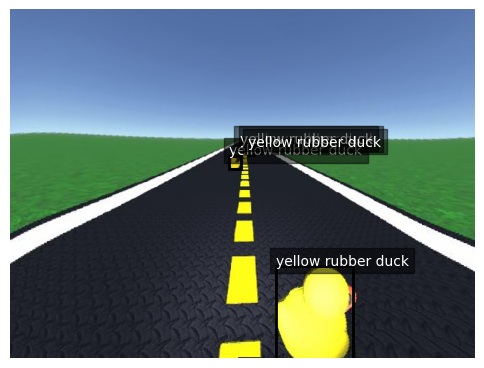

In [20]:
train_images = TRAIN_DIR / "images"
train_labels = TRAIN_DIR / "labels"

img = next(train_images.glob("*.png"))

visualize_labels_for_image(
    img_path=img,
    labels_dir=train_labels,
    class_names=load_classes(),
)

## Training Setup

In [1]:
!pip install -q ultralytics numpy

# And we're ready to train! This step will take about 5 minutes.

Notice that we're only training for 10 epochs. That's probably not enough!

You can modify the config file in `classes.yaml` to update the class lists. If you have done so previously for the autolabelling or you can keep it as is.

In [4]:
import argparse
from pathlib import Path
from ultralytics import YOLO

# training from scratch - you can play around with different yolo models if you wish
model = YOLO("yolo11n.yaml")

runs_root = DATASET_DIR / "runs"
run_name = "duckietown_detection"

model.train(
    data=str(CLASSES_YAML),
    epochs=10,
    imgsz=(480,640),
    batch=16,
    workers=2,
    project=str(runs_root),
    name=run_name,
)

Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/duckietown_dataset/classes.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=(480, 640), int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=duckietown_detection3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d0f226035c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

###You can check the `runs_root` to see the confusion matrix, percision/recall/ROC plots, and some sample visualization.

## Export your best model to ONNX

In [6]:
import os
import numpy as np

all_exps = os.listdir(f"{DATASET_DIR}/runs")
all_exps_filtered = map(lambda x: int(x.replace("duckietown_dataset", "1")), filter(lambda x: x.startswith("exp"), all_exps))
all_exps_filtered = np.array(list(all_exps))
latest_exp_index = np.argmax(all_exps)
latest_exp = all_exps[latest_exp_index]
print(f"Latest exp is {latest_exp}")

Latest exp is duckietown_detection3


In [12]:
run_dir = DATASET_DIR / "runs" / f"{latest_exp}" # you may need to update this based on you run_id
best = run_dir / "weights" / "best.pt"
model_path = DATASET_DIR / "weights" / "best.onnx"

if not best.exists():
    raise FileNotFoundError(f"Could not find best.pt at: {best}")

print(f"Using checkpoint: {best}")
model = YOLO(str(best))

onnx_tmp = run_dir / "weights" / "best.onnx"
print(f"Exporting ONNX to: {onnx_tmp}")

model.export(
    format="onnx",
    opset=18,
    imgsz=(480,640), # (height, width)
    simplify=True,
    dynamic=False,
    nms=True,
    half=True,
    batch=1,
    optimize=False,
    )

model_path.parent.mkdir(parents=True, exist_ok=True)

model_path.write_bytes(onnx_tmp.read_bytes())

print(f"Copied ONNX model to: {model_path}")
print("Export finished successfully.")

Using checkpoint: /content/duckietown_dataset/runs/duckietown_detection3/weights/best.pt
Exporting ONNX to: /content/duckietown_dataset/runs/duckietown_detection3/weights/best.onnx
Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
WARNING ⚠️ half=True only compatible with GPU export, i.e. use device=0, setting half=False.
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from '/content/duckietown_dataset/runs/duckietown_detection3/weights/best.pt' with input shape (1, 3, 480, 640) BCHW and output shape(s) (1, 300, 6) (5.2 MB)

ONNX: starting export with onnx 1.19.1 opset 18...
ONNX: slimming with onnxslim 0.1.77...
ONNX: export success ✅ 1.5s, saved as '/content/duckietown_dataset/runs/duckietown_detection3/weights/best.onnx' (10.1 MB)

Export complete (1.8s)
Results saved to /content/duckietown_dataset/runs/duckietown_detection3/weights
Predict:         yolo predict task=detect model=/content/ducki

# Next, you can download your model and place it in your local `lx-object-dection/assets/` folder to later test the agents behavior!

Make sure you have downloaded the `.onnx` file before moving to the next notebook.

# Done!

We're done training! You can now close this tab and go back to the `Training` notebook